## Prétraitement 

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from PIL import Image

In [11]:
def ranktransform(x):
    """
    Rank transform of the image input x
    Computes the rank of the intensity of each pixel x in its 7x7 neighborhood
    """
    image = np.array(x, dtype=np.float32)

    # Traitement des problèmes de bord
    pad = 3 # 7 // 2
    padded = np.pad(image, pad, mode='reflect')

    H, W = image.shape
    rtImage = np.zeros((H, W), dtype=np.float32)
    for x in range(-pad, pad + 1):
        for y in range(-pad, pad + 1):
            if y == 0 and x == 0:  #pixel central
                continue
            neighbor = padded[pad + y: pad + y + H, pad + x: pad + x + W]
            rtImage += (neighbor < image).astype(np.float32)
 
    return rtImage

In [12]:
def test_tableau():
    img = np.ones((9, 9), dtype=np.float32) * 0.5
    img[6, 5] = 0.0  
    img[5, 6] = 5.0
    rt = ranktransform(img)
    print(rt)

test_tableau()

[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  1.  1.  1.  1.  1.  2.]
 [ 0.  0.  1.  1.  1.  1.  1.  1.  2.]
 [ 0.  0.  1.  1.  1.  1. 48.  1.  2.]
 [ 0.  0.  1.  1.  1.  0.  1.  1.  2.]
 [ 0.  0.  2.  2.  2.  2.  2.  2.  4.]
 [ 0.  0.  2.  2.  2.  2.  2.  2.  4.]]


Le rang attendu en un minimum est 0. A contrario sur un maximum on attent 48 en rang. 

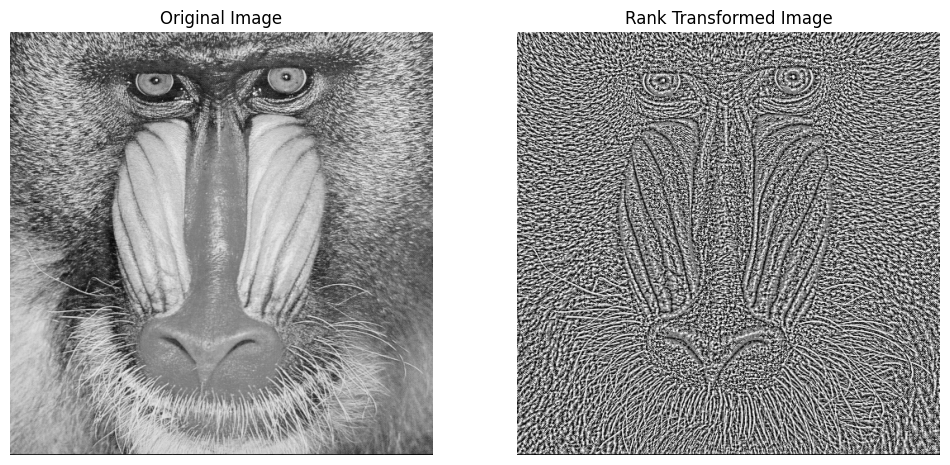

In [15]:
def test_image():
    img = Image.open('./IMG_InPut/babbon.png').convert('L')
    rt = ranktransform(img)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Rank Transformed Image")
    plt.imshow(rt, cmap='gray')
    plt.axis('off')

    plt.show()
test_image()